# Audit preprocessing aroma molekul tunggal
**Dataset:** audited-20260904-v2 · **Tanggal audit:** 9 September 2026

Notebook ini menelusuri 15 tabel dari lima sumber Pyrfume, memakai fungsi produksi yang sama, lalu membuktikan kesamaan hasil dengan artefak beku. Notebook tidak melatih model dan tidak mengubah dataset atau protokol. Output audit disimpan di **reports/preprocessing_20260909/**.

**Pertanyaan penelitian:** dari struktur **satu molekul**, deskriptor aroma apa saja yang mungkin berkaitan dengannya? Input bukan resep campuran. Output bukan molekul baru, persentase bahan, intensitas, atau ketahanan parfum.

Jalankan sel berurutan dengan Python proyek dan RDKit versi yang sesuai. EDA label dan fitur dibatasi pada **development set**. Label mentah seluruh sumber diproses untuk mereproduksi pemisahan awal; array test tersimpan tidak dibuka dan kinerja test tidak dihitung.

## 1. Lingkungan, konfigurasi, dan jejak sumber
Konfigurasi dibaca eksplisit. Semua berkas sumber harus tersedia lokal. SHA-256 diperiksa sebelum pemrosesan. Ini membuktikan identitas snapshot, bukan menjamin kebenaran setiap anotasi manusia.

In [1]:
import os
import sys
import json
from pathlib import Path
from collections import defaultdict
from unittest.mock import patch
for key in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[key] = "1"
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next(p for p in candidates if (p / "src/build_dataset.py").is_file()
            and (p / "data/builds/audited-20260904-v2").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from rdkit import rdBase, Chem
from rdkit.Chem import Draw
from sklearn.preprocessing import MultiLabelBinarizer
from src.config import load_config
from src.artifacts import digest
from src.data_acquisition import load_all
from src.build_dataset import _attach_smiles, _cas_bridge, _attach_sigma, _truthy, METADATA
from src.label_harmonization import LabelHarmonizer, normalize
from src.featurize import FeatureSpec, canonical_smiles, fingerprint_matrix, DESCRIPTORS
from src.splits import split_indices
if "get_ipython" in globals():
    get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.max_rows", 30)
OUT = ROOT / "reports/preprocessing_20260909"
OUT.mkdir(parents=True, exist_ok=True)
BUILD = ROOT / "data/builds/audited-20260904-v2"
cfg = load_config(ROOT / "config.safe-training.yaml")
manifest = json.loads((BUILD / "dataset_manifest.json").read_text(encoding="utf-8"))
manifest_hash_before = digest(BUILD / "dataset_manifest.json")
assert cfg["data_revision"] == manifest["source_revision"]
assert manifest["dataset_id"] == "5c0b0e7c9a56eb60fbc344fc3b6629a160dfa723fdb7b6ba398e621870f2f558"
print("Python:", sys.version.split()[0], "| RDKit:", rdBase.rdkitVersion)
print("Snapshot:", manifest["source_revision"])
print("Dataset:", manifest["dataset_id"])
def show_figure(fig, filename):
    fig.savefig(OUT / filename, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

Python: 3.12.14 | RDKit: 2026.03.4
Snapshot: 8054ea98ed675005ec10e67359902f500e4911b0
Dataset: 5c0b0e7c9a56eb60fbc344fc3b6629a160dfa723fdb7b6ba398e621870f2f558


In [2]:
snapshot = cfg["paths"]["data_raw"] / cfg["data_revision"]
for rel, info in manifest["sources"].items():
    path = snapshot / rel
    assert path.is_file(), f"Snapshot lokal tidak lengkap: {rel}"
    assert digest(path) == info["sha256"], f"Isi sumber berubah: {rel}"
with patch("src.data_acquisition.requests.get",
           side_effect=RuntimeError("Notebook hanya memakai snapshot lokal")):
    dfs, loaded_sources = load_all(save_raw=False, config=cfg)
assert loaded_sources == manifest["sources"]
inventory = pd.DataFrame([
    {"source": source, "table": kind, "rows": len(dfs[f"{source}_{kind}"]),
     "columns": len(dfs[f"{source}_{kind}"].columns), "file": rel}
    for source, files in cfg["sources"].items() for kind, rel in files.items()
])
display(inventory)
inventory.to_csv(OUT / "source_inventory.csv", index=False)
print("PASS: 15 tabel identik dengan snapshot; tidak ada unduhan.")

PASS: 15 tabel identik dengan snapshot; tidak ada unduhan.


,source,table,rows,columns,file
0,goodscents,molecules,4565,5,goodscents/molecules.csv
1,goodscents,behavior,4626,2,goodscents/behavior.csv
2,goodscents,stimuli,4626,5,goodscents/stimuli.csv
3,leffingwell,molecules,3522,5,leffingwell/molecules.csv
4,leffingwell,behavior,3522,114,leffingwell/behavior.csv
5,leffingwell,stimuli,3522,7,leffingwell/stimuli.csv
6,arctander,molecules,2751,5,arctander_1960/molecules.csv
7,arctander,behavior,3102,2,arctander_1960/behavior_1_sparse.csv
8,arctander,stimuli,3102,4,arctander_1960/stimuli.csv
9,sigma,molecules,867,5,sigma_2014/molecules.csv


## 2. Skema data dan handling missing values
**molecules** menyimpan identitas/struktur; **stimuli** menjadi jembatan identitas; **behavior** menyimpan anotasi aroma. Jumlah baris ketiganya tidak harus sama. Jangan menggabungkan berdasarkan posisi baris.

**SMILES/identitas yang hilang tidak diimputasi** dengan nilai rata-rata atau molekul lain. Deskriptor kosong tidak ditebak. Label yang tidak tercatat diperlakukan kode produksi sebagai negatif, tetapi **bukan bukti eksperimental bahwa aroma tidak ada**. Pisahkan asumsi anotasi dari missing value numerik.

In [3]:
schema_rows = []
for source in cfg["sources"]:
    frame = dfs[f"{source}_behavior"]
    text_col = "Labels" if source == "arctander" else "Descriptors"
    present = text_col in frame
    schema_rows.append({
        "source": source, "behavior_rows": len(frame),
        "label_format": "semicolon text" if present else "indicator columns",
        "missing_stimulus": int(frame["Stimulus"].isna().sum()),
        "missing_descriptor_cell": int(frame[text_col].isna().sum()) if present else None,
    })
display(pd.DataFrame(schema_rows))
display(dfs["goodscents_behavior"][["Stimulus", "Descriptors"]].head(4))
print("Kolom contoh molecules:", list(dfs["goodscents_molecules"].columns))

Kolom contoh molecules: ['CID', 'MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name']


,source,behavior_rows,label_format,missing_stimulus,missing_descriptor_cell
0,goodscents,4626,semicolon text,0,4.0
1,leffingwell,3522,indicator columns,0,NaN
2,arctander,3102,semicolon text,0,275.0
3,sigma,941,indicator columns,0,NaN
4,flavornet,716,semicolon text,0,0.0


,Stimulus,Descriptors
0,100-06-1,sweet;vanilla;cherry maraschino cherry;powdery;anisic;balsamic;haw...
1,100-09-4,phenolic;animal;fecal;medicinal
2,100-42-5,sweet;plastic;floral;balsamic
3,100-51-6,sweet;floral;rose;fruity;phenolic;balsamic;chemical


## 3. Join eksplisit: Stimulus → CID → SMILES
Empat sumber memakai jembatan Stimulus/CID. Join **many_to_one** menolak pemetaan kunci yang bertentangan. CAS Sigma diselesaikan melalui identitas konsisten dari sumber lain: seluruh alias CAS suatu stimulus harus dikenal dan menuju satu struktur kanonik yang sama. Aturan konservatif ini dapat mengurangi cakupan Sigma.

**unmapped_identity** berarti struktur tidak ditemukan lewat join, bukan otomatis SMILES salah.

In [4]:
frames = {
    source: _attach_smiles(dfs[f"{source}_behavior"], dfs[f"{source}_stimuli"],
                           dfs[f"{source}_molecules"])
    for source in cfg["sources"] if source != "sigma"
}
with rdBase.BlockLogs():
    cas_map, ambiguous_cas = _cas_bridge(dfs, frames)
    frames["sigma"], sigma_exclusions = _attach_sigma(
        dfs["sigma_behavior"], dfs["sigma_stimuli"], cas_map)
assert ambiguous_cas == manifest["ambiguous_cas_excluded"]
assert sigma_exclusions == manifest["sigma_identity_exclusions"]
display(pd.DataFrame([
    {"source": source, "rows_after_join": len(frame),
     "missing_smiles_after_join": int(frame["__smiles__"].isna().sum())}
    for source, frame in frames.items()
]))
display(frames["goodscents"][["Stimulus", "__cid__", "__smiles__"]].head(4))
print("CAS ambigu dikeluarkan:", len(ambiguous_cas))
print("Kelompok identitas Sigma yang dikeluarkan:", len(sigma_exclusions))

CAS ambigu dikeluarkan: 419
Kelompok identitas Sigma yang dikeluarkan: 199


,source,rows_after_join,missing_smiles_after_join
0,goodscents,4626,0
1,leffingwell,3522,0
2,arctander,3102,278
3,flavornet,716,0
4,sigma,941,204


,Stimulus,__cid__,__smiles__
0,100-06-1,7476,CC(=O)C1=CC=C(C=C1)OC
1,100-09-4,7478,COC1=CC=C(C=C1)C(=O)O
2,100-42-5,7501,C=CC1=CC=CC=C1
3,100-51-6,244,C1=CC=C(C=C1)CO


## 4. Validasi RDKit, canonicalization, dan harmonisasi label
Urutan produksi: struktur harus dapat diparse/disanitasi RDKit, beratom, dan memiliki **satu fragmen terhubung**; kemudian disimpan sebagai canonical isomeric SMILES. Notasi berfragmen dengan titik, termasuk beberapa garam, ditolak oleh batas tugas ini. Belum ada standardisasi tautomer, netralisasi, optimasi 3D, atau verifikasi volatilitas.

Taksonomi awal berasal dari nama kolom Leffingwell. Label teks dipisah dengan titik koma, dinormalisasi, lalu dicocokkan melalui **exact match → daftar sinonim → unmapped**. Tidak ada fuzzy matching atau tebakan label. Sinonim yang menuju kelas yang tersedia belum tentu benar secara semantik; masih memerlukan peninjauan.

Suh et al. menggunakan harmonisasi berpedoman IFRA dengan pakar. Pipeline ini memakai taksonomi Leffingwell dan aturan kode, sehingga tidak boleh disebut reproduksi identik dari kurasi Suh.

In [5]:
taxonomy = sorted({normalize(c) for c in dfs["leffingwell_behavior"]
                   if c.lower() not in METADATA})
harmonizer = LabelHarmonizer(taxonomy)
merged, provenance, audit, rejected = defaultdict(set), [], {}, []
no_label_records = []
with rdBase.BlockLogs():
    for source, frame in frames.items():
        counts = {"rows": len(frame), "unmapped_identity": 0,
                  "invalid_or_multifragment": 0, "accepted": 0,
                  "no_mapped_labels": 0}
        for _, row in frame.iterrows():
            raw_smiles = row["__smiles__"]
            record = {"source": source, "stimulus": str(row["Stimulus"])}
            if not isinstance(raw_smiles, str):
                counts["unmapped_identity"] += 1
                rejected.append({**record, "reason": "unmapped_identity"})
                continue
            canonical = canonical_smiles(raw_smiles)
            if canonical is None:
                counts["invalid_or_multifragment"] += 1
                rejected.append({**record, "reason": "invalid_or_multifragment"})
                continue
            if source in ("leffingwell", "sigma"):
                raw_terms = [c for c in frame if c.lower() not in METADATA
                             and not c.startswith("__") and _truthy(row[c])]
                labels = {harmonizer.map_descriptor(c) for c in raw_terms}
                labels.discard(None)
                raw_labels = ";".join(raw_terms)
            else:
                field = "Labels" if source == "arctander" else "Descriptors"
                raw_labels = row.get(field, "")
                labels = harmonizer.map_row(raw_labels)
            if labels:
                merged[canonical].update(labels)
                provenance.append({**record, "smiles": canonical,
                                   "labels": sorted(labels)})
                counts["accepted"] += 1
            else:
                counts["no_mapped_labels"] += 1
                no_label_records.append({**record, "smiles": canonical,
                    "raw_labels": raw_labels, "reason": "no_mapped_labels"})
        audit[source] = counts
for source, counts in audit.items():
    original = {k: v for k, v in counts.items() if k != "no_mapped_labels"}
    assert original == manifest["source_audit"][source]
    assert counts["rows"] == sum(counts[k] for k in
        ["accepted", "unmapped_identity", "invalid_or_multifragment", "no_mapped_labels"])
assert provenance == json.loads((BUILD / "provenance.json").read_text(encoding="utf-8"))
assert rejected == json.loads((BUILD / "rejected_records.json").read_text(encoding="utf-8"))
audit_df = pd.DataFrame.from_dict(audit, orient="index").rename_axis("source")
display(audit_df)
print("Ukuran taksonomi awal:", len(taxonomy))
print("Baris tanpa label terpetakan:", len(no_label_records))
audit_df.to_csv(OUT / "source_attrition.csv")
pd.DataFrame(no_label_records).to_csv(OUT / "no_mapped_label_records.csv", index=False)

Ukuran taksonomi awal: 113
Baris tanpa label terpetakan: 739


,rows,unmapped_identity,invalid_or_multifragment,accepted,no_mapped_labels
source,,,,,
goodscents,4626,0,183,4259,184
leffingwell,3522,0,0,3522,0
arctander,3102,278,102,2433,289
flavornet,716,0,0,483,233
sigma,941,204,0,704,33


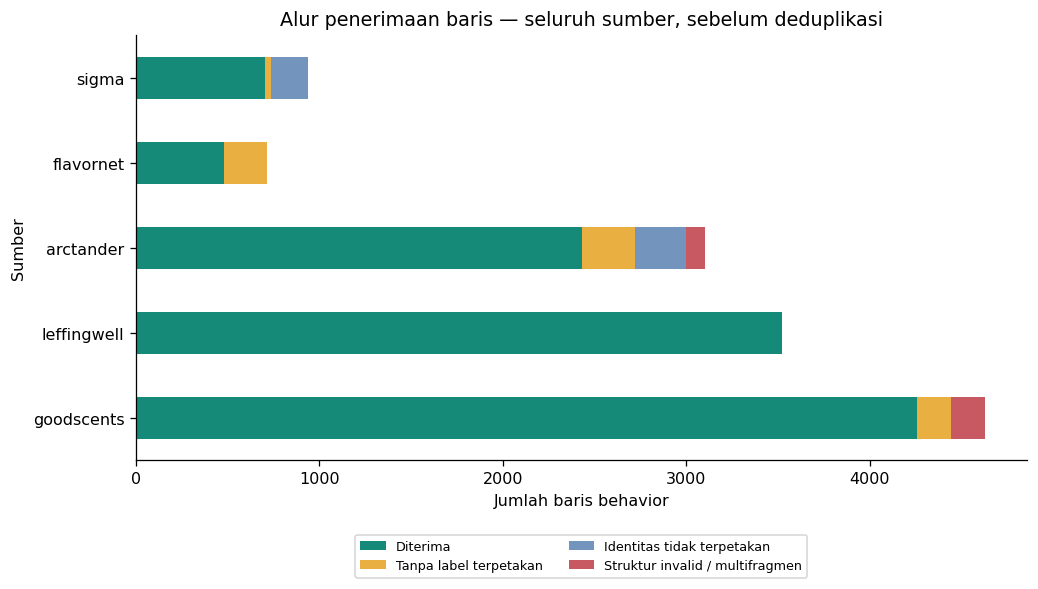

,descriptor,count
0,powdery,185
1,jasmin,145
2,camphoraceous,121
3,hyacinth,112
4,musky,106
5,geranium,98
6,clean,92
7,lily,86
8,amber,84
9,caramelic,81


,source,stimulus,smiles,raw_labels,reason
0,goodscents,1003050-32-5,CC1CCCCC1NC(=O)c1c(F)c(F)c(F)c(F)c1F,cooling,no_mapped_labels
1,goodscents,10191-41-0,Cc1c(C)c2c(c(C)c1O)CC[C@@](C)(CCC[C@H](C)CCC[C@H](C)CCCC(C)C)O2,bland,no_mapped_labels
2,goodscents,10352-88-2,CCCC/C=C/C(=O)O,rancid,no_mapped_labels
3,goodscents,10482-53-8,C=CCCCCC/C=C\C/C=C\C/C=C\CC,costus,no_mapped_labels
4,goodscents,105657-89-4,CCC=CCC=CCC=CCCC(C)=O,shrimp,no_mapped_labels


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
status_cols = ["accepted", "no_mapped_labels", "unmapped_identity", "invalid_or_multifragment"]
audit_df[status_cols].plot.barh(stacked=True, ax=ax,
    color=["#168a79", "#e9af40", "#7394bc", "#c85962"])
ax.set(xlabel="Jumlah baris behavior", ylabel="Sumber",
       title="Alur penerimaan baris — seluruh sumber, sebelum deduplikasi")
ax.legend(["Diterima", "Tanpa label terpetakan", "Identitas tidak terpetakan",
           "Struktur invalid / multifragmen"], loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8)
show_figure(fig, "01_source_attrition.png")
unmapped_df = harmonizer.unmapped_report()
pd.testing.assert_frame_equal(unmapped_df, pd.read_csv(BUILD / "unmapped_descriptors.csv"))
display(unmapped_df.head(15))
display(pd.DataFrame(no_label_records).head(5))
unmapped_df.to_csv(OUT / "unmapped_descriptors.csv", index=False)

## 5. Deduplikasi dan kontribusi tiap sumber
Satu canonical SMILES menjadi satu sampel; label dari baris/sumber yang cocok digabung melalui union. Deduplikasi dilakukan **sebelum split** agar identitas sama tidak menjadi sampel train dan test sekaligus.

Gabungan adalah union, bukan hanya irisan molekul di seluruh sumber. Overlap dapat menambah anotasi bagi molekul yang sudah ada. Tabel menghitung kontribusi yang unik terhadap empat sumber lain, tanpa bergantung urutan penggabungan. Cakupan belum membuktikan peningkatan akurasi. Sumber tidak otomatis independen satu sama lain.

Pada snapshot ini, Sigma tidak menambah molekul eksklusif; ia menambah 738 pasangan molekul–label eksklusif pada taksonomi awal. Nol molekul eksklusif juga dipengaruhi aturan join Sigma yang memerlukan identitas dari sumber lain. Jumlah pasangan ini bukan jumlah label kelas baru atau bukti peningkatan performa.

Baris anotasi diterima: 11401 | Molekul unik gabungan: 6703


,accepted_rows,unique_molecules_in_source,molecules_exclusive_to_source,molecule_label_pairs_exclusive_to_source
source,,,,
goodscents,4259,4203,1681,9723
leffingwell,3522,3522,1157,7640
arctander,2433,2376,1117,3721
flavornet,483,483,51,196
sigma,704,704,0,738


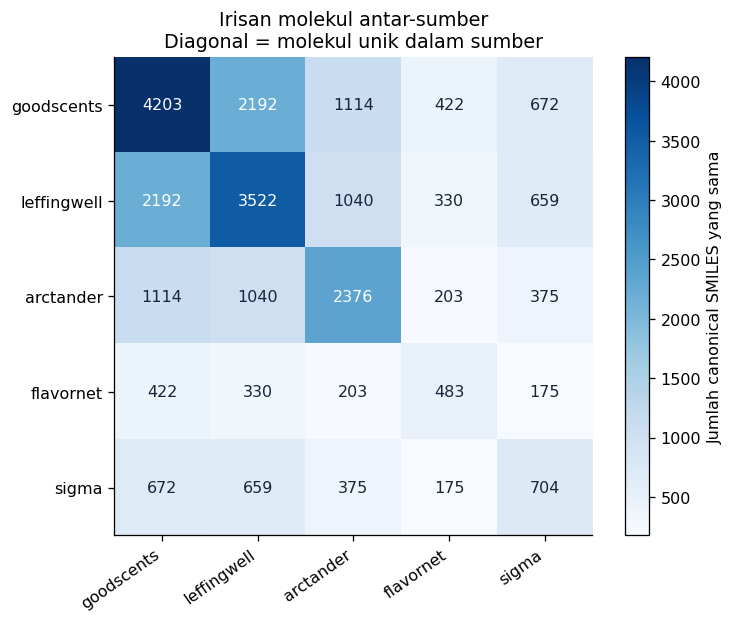

In [7]:
source_sets, source_pairs = defaultdict(set), defaultdict(set)
for row in provenance:
    source_sets[row["source"]].add(row["smiles"])
    source_pairs[row["source"]].update((row["smiles"], label) for label in row["labels"])
source_order = list(frames)
contribution_rows = []
for source in source_order:
    others = [s for s in source_order if s != source]
    other_molecules = set().union(*(source_sets[s] for s in others))
    other_pairs = set().union(*(source_pairs[s] for s in others))
    contribution_rows.append({
        "source": source, "accepted_rows": audit[source]["accepted"],
        "unique_molecules_in_source": len(source_sets[source]),
        "molecules_exclusive_to_source": len(source_sets[source] - other_molecules),
        "molecule_label_pairs_exclusive_to_source": len(source_pairs[source] - other_pairs),
    })
contributions = pd.DataFrame(contribution_rows).set_index("source")
overlap = pd.DataFrame([[len(source_sets[a] & source_sets[b]) for b in source_order]
                       for a in source_order], index=source_order, columns=source_order)
display(contributions)
print("Baris anotasi diterima:", len(provenance), "| Molekul unik gabungan:", len(merged))
contributions.to_csv(OUT / "source_contributions.csv")
overlap.to_csv(OUT / "source_overlap_counts.csv")
fig, ax = plt.subplots(figsize=(7.4, 5.4))
im = ax.imshow(overlap.values, cmap="Blues")
ax.set_xticks(range(len(source_order)), source_order, rotation=35, ha="right")
ax.set_yticks(range(len(source_order)), source_order)
for i in range(len(source_order)):
    for j in range(len(source_order)):
        value = int(overlap.iloc[i, j])
        ax.text(j, i, str(value), ha="center", va="center",
                color="white" if value > overlap.values.max() / 2 else "#15263a")
ax.set_title("Irisan molekul antar-sumber\nDiagonal = molekul unik dalam sumber")
fig.colorbar(im, ax=ax, label="Jumlah canonical SMILES yang sama")
show_figure(fig, "02_source_overlap.png")

## 6. Encoding awal dan reproduksi split
Label adalah **multi-hot**: satu molekul dapat memiliki beberapa nilai 1. MultiLabelBinarizer dipakai sebagai pemeriksaan independen atas encoding keanggotaan-set pada builder produksi, dengan urutan kelas dikunci.

Split luar memakai iterative multilabel stratification, seed 42, proporsi target 80:20. Hasil integer dapat sedikit berbeda dari 80:20 tepat. **Development bukan seluruhnya data fit**: tahap training membaginya lagi untuk CV, early stopping, dan pemilihan threshold. Test tidak digunakan untuk keputusan tersebut.

In [8]:
smiles = sorted(merged)
mlb = MultiLabelBinarizer(classes=taxonomy)
Y_full = mlb.fit_transform([sorted(merged[s]) for s in smiles]).astype(np.uint8)
Y_manual = np.asarray([[int(label in merged[s]) for label in taxonomy] for s in smiles],
                      dtype=np.uint8)
np.testing.assert_array_equal(Y_full, Y_manual)
assert manifest["split"]["strategy"] == "multilabel_random"
train, test = split_indices(Y_full, cfg["split"]["test_size"], cfg["seed"])
np.testing.assert_array_equal(train, manifest["split"]["train"])
np.testing.assert_array_equal(test, manifest["split"]["test"])
assert not set(train) & set(test)
assert len(set(train) | set(test)) == len(smiles)
assert not {smiles[i] for i in train} & {smiles[i] for i in test}
print({"unique_molecules": len(smiles), "development": len(train),
       "test": len(test), "identity_overlap": 0, "initial_taxonomy": len(taxonomy)})

{'unique_molecules': 6703, 'development': 5383, 'test': 1320, 'identity_overlap': 0, 'initial_taxonomy': 113}


## 7. Memilih 25 target berdasarkan development
Label kandidat harus memiliki ≥30 positif di development; maksimum 25 dipilih menurut frekuensi, lalu disimpan dalam urutan kelas tetap. Ini mendefinisikan ruang lingkup tugas, bukan memastikan label langka sudah terwakili. Label selection tidak menggunakan frekuensi test.

Molekul yang semula memiliki label di luar 25 target tetap dapat menjadi baris all-zero pada target terpilih. **All-zero bukan kelas odorless** dan tidak boleh diterjemahkan menjadi “tidak berbau”. Pemilihan 25 kelas tidak diulang per fold.

In [9]:
counts = Y_full[train].sum(axis=0)
blocked = set(cfg["labels"]["blocklist"])
candidates = [i for i, label in enumerate(taxonomy)
              if counts[i] >= cfg["labels"]["min_positive_count"] and label not in blocked]
chosen = sorted(sorted(candidates, key=lambda i: (-int(counts[i]), taxonomy[i]))
                [:cfg["labels"]["max_labels"]])
labels = [taxonomy[i] for i in chosen]
assert labels == manifest["labels"]
Y_dev = Y_full[np.ix_(train, chosen)]
stored_Y_dev = sp.load_npz(BUILD / "Y_train.npz").toarray()
np.testing.assert_array_equal(Y_dev, stored_Y_dev)
dev_smiles = [smiles[i] for i in train]
assert dev_smiles == (BUILD / "smiles_train.txt").read_text(encoding="utf-8").splitlines()
label_counts = pd.DataFrame({"label": labels, "positive_count": Y_dev.sum(axis=0)})
label_counts["prevalence"] = label_counts["positive_count"] / len(train)
cardinality = Y_dev.sum(axis=1)
display(label_counts.sort_values("positive_count", ascending=False).reset_index(drop=True))
print("Target all-zero development:", int((cardinality == 0).sum()))
label_counts.to_csv(OUT / "development_label_distribution.csv", index=False)

Target all-zero development: 381


,label,positive_count,prevalence
0,fruity,1942,0.360765
1,green,1593,0.295932
2,floral,1360,0.252647
3,sweet,1259,0.233884
4,herbal,986,0.183169
5,woody,821,0.152517
6,fatty,610,0.113320
7,oily,532,0.098830
8,spicy,509,0.094557
9,fresh,458,0.085083


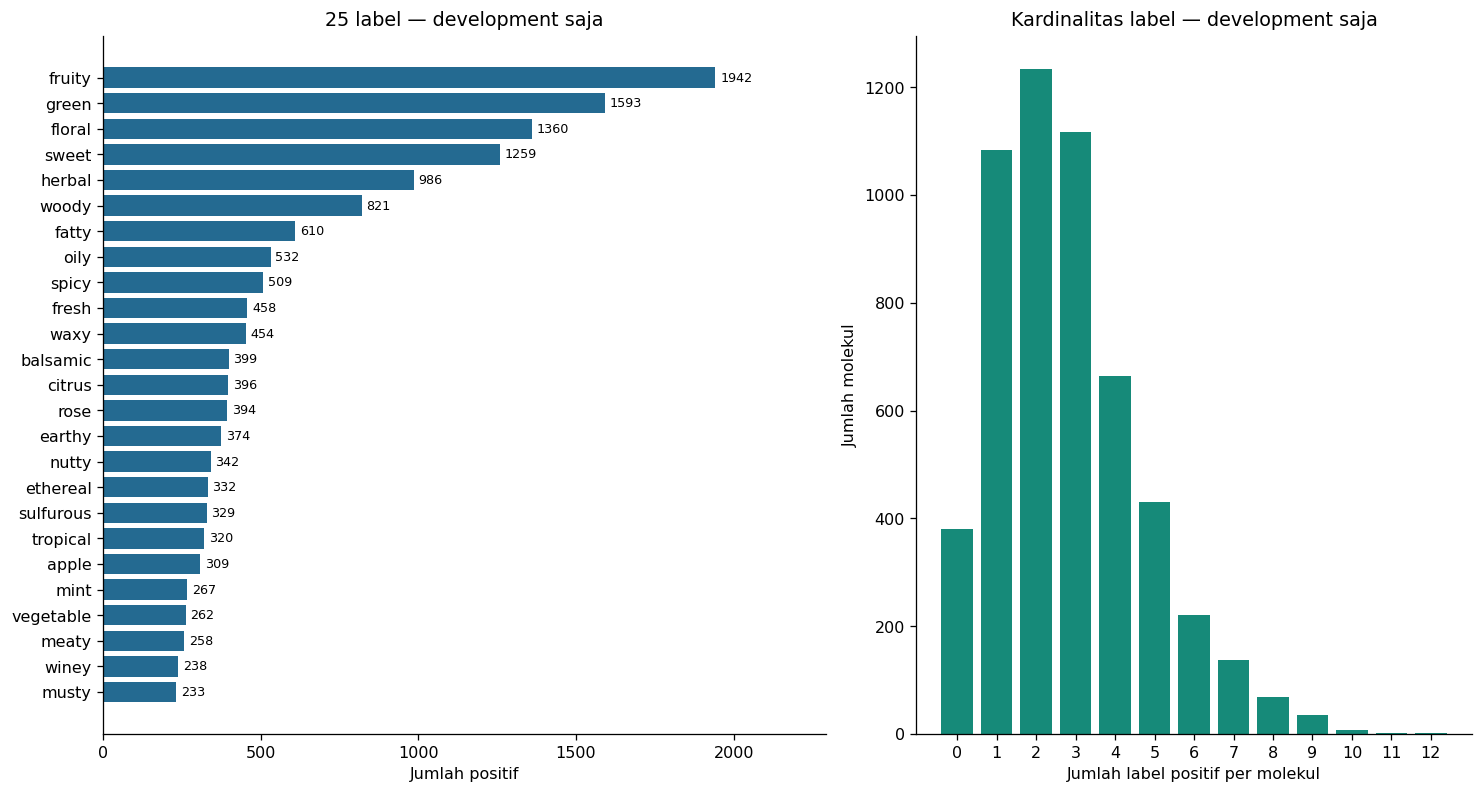

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [1.3, 1]})
ordered = label_counts.sort_values("positive_count")
axes[0].barh(ordered["label"], ordered["positive_count"], color="#246a91")
axes[0].set(xlabel="Jumlah positif", title="25 label — development saja")
for i, value in enumerate(ordered["positive_count"]):
    axes[0].text(int(value) + 15, i, str(value), va="center", fontsize=8)
axes[0].set_xlim(0, ordered["positive_count"].max() * 1.18)
freq = pd.Series(cardinality).value_counts().sort_index()
axes[1].bar(freq.index, freq.values, color="#168a79")
axes[1].set(xlabel="Jumlah label positif per molekul", ylabel="Jumlah molekul",
            title="Kardinalitas label — development saja")
axes[1].set_xticks(freq.index)
fig.tight_layout()
show_figure(fig, "03_development_labels.png")

## 8. RDKit feature extraction: SMILES → 2.053 angka
Fitur memakai Morgan radius 2, 2.048 bit, chirality aktif, ditambah **MolWt, MolLogP, NumHDonors, NumHAcceptors, TPSA** dalam urutan tetap.

Morgan merepresentasikan lingkungan atom dalam graf, bukan 2.048 bahan parfum. Chirality mencatat stereokimia yang tersedia pada input; tidak menebak stereokimia yang hilang. Lima deskriptor adalah fitur, bukan label aroma.

Spesifikasi diambil dari manifest agar tidak tanpa sengaja memakai default FeatureSpec() yang berbeda pada chirality. Tidak ada normalisasi/skaling atau imputasi numerik dalam builder ini; fitur wajib finite. Seluruh fitur development dihitung ulang dan dicocokkan **nilai per nilai**, bukan hanya dimensinya.

X development: (5383, 2053) | Y development: (5383, 25)
Rata-rata bit Morgan aktif: 0.011334056966006756
PASS: fitur dan label development identik dengan build beku.


,radius,n_bits,include_chirality,use_descriptors,fragment_policy,dtype,version,rdkit_version
0,2,2048,True,True,single,float32,1,2026.03.4


,canonical_smiles,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA
0,BrC=Cc1ccccc1,183.048004,3.0522,0.0,0.0,0.000000
1,C#CC(C)CO,84.117996,0.2480,1.0,1.0,20.230000
2,C#CC1(C(=O)OC)CCCCC1,166.220001,1.7431,0.0,2.0,26.299999
3,C#CC1(OC(C)=O)CCCCC1,166.220001,1.8856,0.0,2.0,26.299999


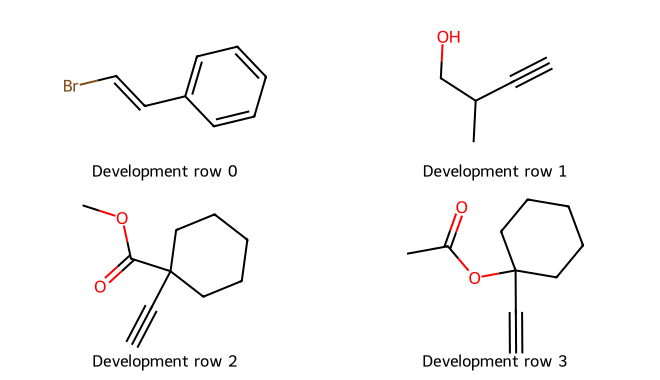

In [11]:
spec = FeatureSpec.from_dict(manifest["feature_spec"])
assert spec.schema_id == manifest["feature_schema_id"]
assert FeatureSpec.from_dict(cfg["fingerprint"]).schema_id == spec.schema_id
with rdBase.BlockLogs():
    X_dev, valid = fingerprint_matrix(dev_smiles, spec)
assert valid.all() and np.isfinite(X_dev).all()
assert X_dev.dtype == np.float32 and X_dev.shape == (len(train), spec.n_features)
stored_X_dev = sp.load_npz(BUILD / "X_train.npz").toarray()
np.testing.assert_array_equal(X_dev, stored_X_dev)
descriptor_df = pd.DataFrame(X_dev[:, spec.n_bits:], columns=DESCRIPTORS)
display(pd.DataFrame([spec.to_dict()]))
display(pd.concat([pd.Series(dev_smiles[:4], name="canonical_smiles"),
                   descriptor_df.head(4).reset_index(drop=True)], axis=1))
print("X development:", X_dev.shape, "| Y development:", Y_dev.shape)
print("Rata-rata bit Morgan aktif:", float(X_dev[:, :spec.n_bits].mean()))
print("PASS: fitur dan label development identik dengan build beku.")
display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in dev_smiles[:4]],
                            molsPerRow=2, subImgSize=(330, 190),
                            legends=[f"Development row {i}" for i in range(4)]))

,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA
count,5383.000,5383.000,5383.000,5383.000,5383.000
mean,178.774,2.651,0.345,1.912,26.401
std,60.818,1.470,0.804,1.332,21.346
min,4.003,-17.406,0.000,0.000,0.000
25%,142.242,1.824,0.000,1.000,17.070
50%,172.224,2.598,0.000,2.000,26.300
75%,206.285,3.450,1.000,2.000,29.460
max,1297.128,17.714,24.000,40.000,633.200


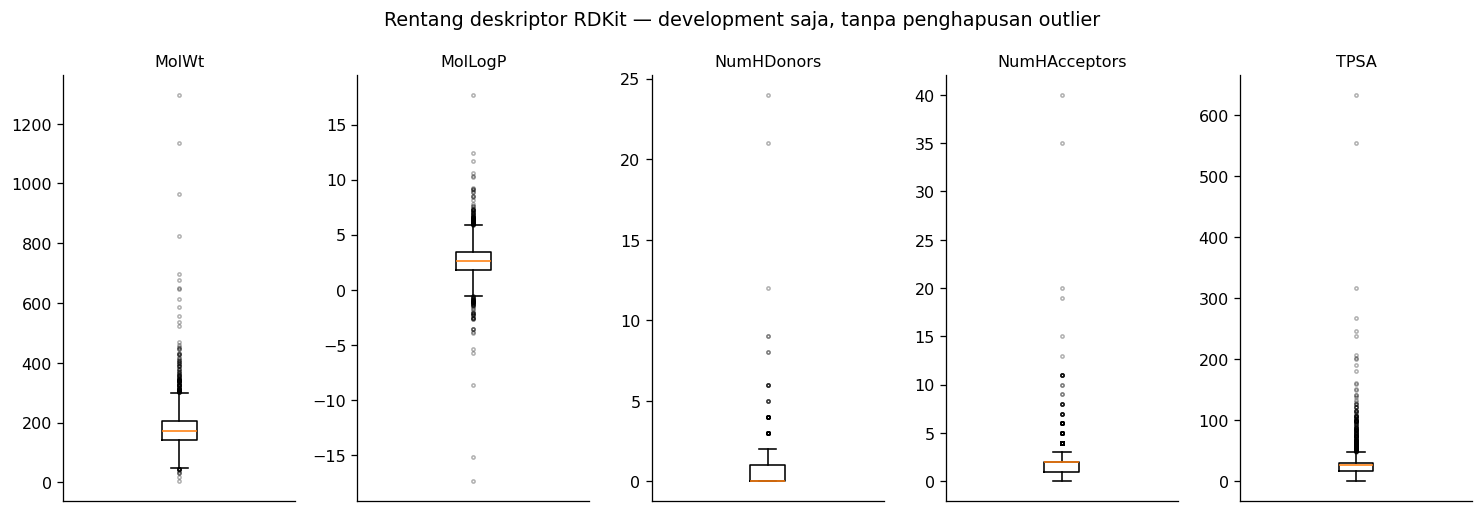

In [12]:
display(descriptor_df.describe().round(3))
fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(13, 4.5))
for ax, column in zip(axes, DESCRIPTORS):
    ax.boxplot(descriptor_df[column], showfliers=True,
               flierprops={"markersize": 2, "alpha": 0.3})
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
fig.suptitle("Rentang deskriptor RDKit — development saja, tanpa penghapusan outlier")
fig.tight_layout()
show_figure(fig, "04_descriptor_ranges.png")
descriptor_df.describe().to_csv(OUT / "development_descriptor_summary.csv")

## 9. Interpretasi dan batas validitas
- **Valid secara sintaks/kimia RDKit belum berarti bahan parfum yang relevan.** Rentang fitur ekstrem memerlukan peninjauan domain, bukan penghapusan otomatis demi skor.
- Label antarsumber dapat tidak lengkap/konsisten. Union menambah cakupan tetapi bisa memperbesar noise. Nol adalah asumsi label tidak tercatat, bukan verifikasi sensoris negatif.
- Aturan sinonim dan descriptor tidak terpetakan perlu ditinjau. Mengubahnya berarti versi dataset/protokol baru; jangan diam-diam mengganti build eksperimen.
- Split identitas terpisah belum menjamin scaffold berbeda; generalisasi ke molekul sangat baru perlu evaluasi scaffold/external.
- Imbalance ditangani hanya di bagian training. Oversampling sebelum split menyebabkan kebocoran. MLSMOTE fitur sintetis tidak menghasilkan senyawa kimia nyata.
- Lima sumber dipilih karena cocok dengan tugas dan dapat dipetakan; kontribusi cakupan bukan bukti bahwa lima sumber optimal. Uji ablation diperlukan untuk mengklaim manfaat penggabungan.
- Visualisasi ini untuk audit kurasi. Tidak ada model, tuning, atau evaluasi test yang dijalankan.

## 10. Pemeriksaan akhir dan artefak
Audit menambahkan kategori **no_mapped_labels** yang sebelumnya tidak tercatat eksplisit pada ringkasan builder. Aturan pemilihan sampel, fitur, label, dan split tidak diubah. Checksum seluruh berkas build tetap diperiksa (membaca byte checksum bukan mendeserialisasi array test).

In [13]:
for filename, expected in manifest["files"].items():
    assert digest(BUILD / filename) == expected, f"Artefak beku berubah: {filename}"
assert digest(BUILD / "dataset_manifest.json") == manifest_hash_before
for rel, info in manifest["sources"].items():
    assert digest(snapshot / rel) == info["sha256"]
summary = {
    "status": "PASS", "dataset_id": manifest["dataset_id"],
    "source_revision": manifest["source_revision"], "sources": source_order,
    "raw_behavior_rows": int(audit_df["rows"].sum()),
    "accepted_annotation_rows": len(provenance),
    "unmapped_identity_rows": int(audit_df["unmapped_identity"].sum()),
    "invalid_or_multifragment_rows": int(audit_df["invalid_or_multifragment"].sum()),
    "no_mapped_label_rows": len(no_label_records),
    "unique_molecules": len(smiles), "initial_taxonomy_labels": len(taxonomy),
    "development_molecules": len(train), "test_molecules": len(test),
    "selected_labels": labels, "n_features": spec.n_features,
    "development_all_zero_targets": int((cardinality == 0).sum()),
    "development_mean_cardinality": float(cardinality.mean()),
    "largest_smallest_positive_count_ratio": float(
        label_counts["positive_count"].max() / label_counts["positive_count"].min()),
    "exact_provenance_match": True, "exact_rejected_records_match": True,
    "exact_unmapped_descriptor_match": True, "exact_outer_split_match": True,
    "exact_development_features_and_labels_match": True,
    "frozen_build_and_raw_hashes_unchanged": True,
    "training_started": False, "test_arrays_deserialized": False,
    "raw_annotations_used_to_reproduce_initial_split": True,
}
(OUT / "audit_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
display(pd.DataFrame([{k: summary[k] for k in [
    "raw_behavior_rows", "accepted_annotation_rows", "unique_molecules",
    "development_molecules", "test_molecules", "n_features",
    "development_all_zero_targets"]}]).T.rename(columns={0: "value"}))
print("PASS: audit selesai; hasil tersimpan pada", OUT.relative_to(ROOT))

PASS: audit selesai; hasil tersimpan pada reports\preprocessing_20260909


,value
raw_behavior_rows,12907
accepted_annotation_rows,11401
unique_molecules,6703
development_molecules,5383
test_molecules,1320
n_features,2053
development_all_zero_targets,381


## Referensi
- [Suh, Hong, dan Park (2025), A comparative study of machine learning models on molecular fingerprints for odor decoding](https://www.nature.com/articles/s42004-025-01651-7).
- [Hamel et al. (2024), Pyrfume: A window to the world's olfactory data](https://www.nature.com/articles/s41597-024-04051-z).
- [Snapshot Pyrfume yang digunakan](https://github.com/pyrfume/pyrfume-data/tree/8054ea98ed675005ec10e67359902f500e4911b0).
- Implementasi lokal: src/data_acquisition.py, src/build_dataset.py, src/label_harmonization.py, src/featurize.py, src/splits.py.
- Angka tabel/plot adalah komputasi snapshot proyek ini, bukan hasil model Suh. Notebook tidak membuktikan kebaruan algoritma, keunggulan tuning, atau akurasi campuran parfum.